# Shanta Interface Development

In [1]:
import pandas as pd
import numpy as np

# Simulated structure for dataset (this would be replaced with actual site data)
# Columns assumed: CN_Concentration, DO_Concentration, Recovery, Fines_Fraction, Avg_Particle_Size

# For demonstration, generate mock data
np.random.seed(42)
n = 5000
df = pd.DataFrame({
    'CN_Concentration': np.random.normal(210, 25, n).clip(120, 300),
    'DO_Concentration': np.random.normal(7.5, 1, n).clip(4, 10),
    'Recovery': np.random.normal(91, 2, n).clip(80, 96),
    'Fines_Fraction': np.random.uniform(0.1, 0.6, n),
    'Avg_Particle_Size': np.random.normal(75, 20, n).clip(20, 150)
})

# Bin CN and DO for a heatmap structure
df['CN_Bin'] = pd.cut(df['CN_Concentration'], bins=np.arange(120, 310, 10))
df['DO_Bin'] = pd.cut(df['DO_Concentration'], bins=np.arange(4, 10.5, 0.5))

# Optionally filter to typical fines range or size range
# e.g., represent operational scenarios where fines are between 0.2 and 0.5
filtered_df = df[(df['Fines_Fraction'] >= 0.2) & (df['Fines_Fraction'] <= 0.5)]

# Group and compute stats
heatmap_data = (
    filtered_df
    .groupby(['CN_Bin', 'DO_Bin'], observed=True)
    .agg(
        Count=('Recovery', 'count'),
        Median_Recovery=('Recovery', 'median'),
        Mean_Recovery=('Recovery', 'mean'),
        Avg_Particle_Size=('Avg_Particle_Size', 'mean')
    )
    .reset_index()
)

heatmap_data


,CN_Bin,DO_Bin,Count,Median_Recovery,Mean_Recovery,Avg_Particle_Size
0,"(120, 130]","(7.5, 8.0]",1,92.182181,92.182181,96.251440
1,"(130, 140]","(5.5, 6.0]",1,90.746024,90.746024,55.154606
2,"(130, 140]","(6.0, 6.5]",5,90.897210,90.990302,80.801688
3,"(130, 140]","(7.0, 7.5]",1,89.832879,89.832879,66.236378
4,"(130, 140]","(7.5, 8.0]",2,89.518498,89.518498,73.350435
...,...,...,...,...,...,...
146,"(280, 290]","(6.5, 7.0]",1,93.624416,93.624416,52.856004
147,"(280, 290]","(7.0, 7.5]",4,90.985427,91.554651,77.833432
148,"(280, 290]","(7.5, 8.0]",1,90.989918,90.989918,64.623999
149,"(290, 300]","(6.5, 7.0]",1,92.988006,92.988006,64.980175


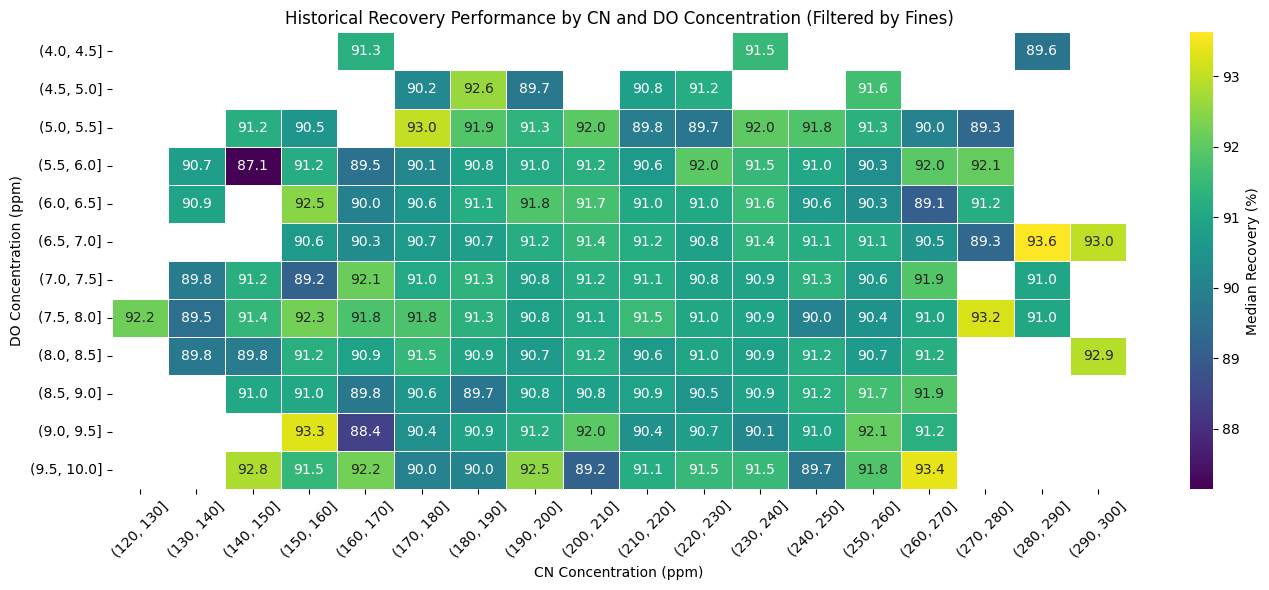

,CN_Bin,DO_Bin,Count,Median_Recovery,Mean_Recovery,Avg_Particle_Size
65,"(190, 200]","(9.5, 10.0]",11,92.513905,92.094458,75.198585
27,"(160, 170]","(7.0, 7.5]",15,92.147118,91.743496,81.661205


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the data for heatmap (using median recovery)
pivot_table = heatmap_data.pivot(index="DO_Bin", columns="CN_Bin", values="Median_Recovery")

# Generate the heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="viridis", linewidths=0.5, cbar_kws={'label': 'Median Recovery (%)'})
plt.title("Historical Recovery Performance by CN and DO Concentration (Filtered by Fines)")
plt.xlabel("CN Concentration (ppm)")
plt.ylabel("DO Concentration (ppm)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Extract top-performing CN/DO zones
top_performing = heatmap_data[
    (heatmap_data["Count"] >= 10) &
    (heatmap_data["Median_Recovery"] >= 92)
].sort_values(by="Median_Recovery", ascending=False)

top_performing
